In [35]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/Dataset/housing.csv")
print(df.head())

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  


In [36]:
#Checking for missing values
df.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [38]:
#Filling the null values of total_bedrooms with median
df["total_bedrooms"] = df["total_bedrooms"].fillna(df["total_bedrooms"].median())

In [39]:
# turn the ocean_proximity text into numbers
# drop_first=True just avoids extra column
df = pd.get_dummies(df, columns=["ocean_proximity"], drop_first=True)
df.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,False,False,True,False


In [40]:
# X = all columns except the one we want to predict
X = df.drop("median_house_value", axis=1)

# y = the column we want to predict
y = df["median_house_value"]

In [41]:
from sklearn.model_selection import train_test_split

# Doing 80/20 Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [42]:
from sklearn.linear_model import LinearRegression

# create the Linear Regression model (no regularization)
model = LinearRegression()

# train the model on the training data
model.fit(X_train, y_train)

LinearRegression()

In [43]:

# put the coefficients in a readable format
coefficients = pd.Series(model.coef_, index=X.columns)

# show all coefficients
print(coefficients)

longitude                     -26838.273372
latitude                      -25468.352050
housing_median_age              1102.185084
total_rooms                       -6.021506
total_bedrooms                   102.789395
population                       -38.172906
households                        48.252753
median_income                  39473.975175
ocean_proximity_INLAND        -39786.656161
ocean_proximity_ISLAND        136125.072615
ocean_proximity_NEAR BAY       -5136.642217
ocean_proximity_NEAR OCEAN      3431.140073
dtype: float64


In [44]:
from sklearn.metrics import mean_squared_error

# make predictions on training and test data
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# calculate Mean Squared Error
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

# show the results
print("Training MSE:", train_mse)
print("Test MSE:", test_mse)

Training MSE: 4683203783.504253
Test MSE: 4908476721.156606


In [45]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import GridSearchCV

In [47]:
# alpha = regularization strength
# we will try several values to see which works best
alpha_grid = {
    "alpha": [0.01, 0.1, 1, 10, 100]
}

In [48]:
# create a Ridge model
ridge = Ridge()

# use GridSearchCV to find the best alpha
ridge_grid = GridSearchCV(
    estimator=ridge,
    param_grid=alpha_grid,
    scoring="neg_mean_squared_error",
    cv=5
)

# fit GridSearchCV on training data
ridge_grid.fit(X_train, y_train)


GridSearchCV(cv=5, estimator=Ridge(),
             param_grid={'alpha': [0.01, 0.1, 1, 10, 100]},
             scoring='neg_mean_squared_error')

In [49]:
# show the alpha value that worked best
print("Best alpha for Ridge:", ridge_grid.best_params_)

# get the best Ridge model
ridge_best = ridge_grid.best_estimator_

# make predictions on the test set
y_test_pred_ridge = ridge_best.predict(X_test)

# calculate MSE on test set
ridge_test_mse = mean_squared_error(y_test, y_test_pred_ridge)

# show the result
print("Ridge Test MSE:", ridge_test_mse)


Best alpha for Ridge: {'alpha': 1}
Ridge Test MSE: 4910037869.229384


In [50]:
lasso = Lasso(max_iter=10000)


lasso_grid = GridSearchCV(
    estimator=lasso,
    param_grid=alpha_grid,
    scoring="neg_mean_squared_error",
    cv=5
)


lasso_grid.fit(X_train, y_train)


GridSearchCV(cv=5, estimator=Lasso(max_iter=10000),
             param_grid={'alpha': [0.01, 0.1, 1, 10, 100]},
             scoring='neg_mean_squared_error')

In [51]:
# show the alpha value that worked best for Lasso
print("Best alpha for Lasso:", lasso_grid.best_params_)

# get the best Lasso model
lasso_best = lasso_grid.best_estimator_

# make predictions on the test set
y_test_pred_lasso = lasso_best.predict(X_test)

# calculate MSE on test set
lasso_test_mse = mean_squared_error(y_test, y_test_pred_lasso)

# show the result
print("Lasso Test MSE:", lasso_test_mse)


Best alpha for Lasso: {'alpha': 0.01}
Lasso Test MSE: 4908478666.800429


In [52]:
lasso_final = Lasso(alpha=0.01, max_iter=10000)
lasso_final.fit(X_train, y_train)

ridge_final = Ridge(alpha=1)
ridge_final.fit(X_train, y_train)


Ridge(alpha=1)

In [53]:
coeff_comparison = pd.DataFrame({
    "Feature": X.columns,
    "Lasso_Coeff": lasso_final.coef_,
    "Ridge_Coeff": ridge_final.coef_
})

print(coeff_comparison)

                       Feature    Lasso_Coeff    Ridge_Coeff
0                    longitude  -26838.273505  -26860.198129
1                     latitude  -25468.369965  -25493.131209
2           housing_median_age    1102.185363    1102.629029
3                  total_rooms      -6.021505      -6.019346
4               total_bedrooms     102.789549     102.927379
5                   population     -38.172912     -38.177632
6                   households      48.252585      48.099003
7                median_income   39473.970982   39470.951501
8       ocean_proximity_INLAND  -39786.594148  -39759.650387
9       ocean_proximity_ISLAND  136083.735964  108852.317864
10    ocean_proximity_NEAR BAY   -5136.499931   -5142.606569
11  ocean_proximity_NEAR OCEAN    3431.059959    3411.167075


In [54]:
# Lasso predictions
y_train_pred_lasso = lasso_final.predict(X_train)
y_test_pred_lasso = lasso_final.predict(X_test)

In [55]:
lasso_train_mse = mean_squared_error(y_train, y_train_pred_lasso)
lasso_test_mse = mean_squared_error(y_test, y_test_pred_lasso)

In [56]:
print("Lasso Train MSE:", lasso_train_mse)
print("Lasso Test MSE:", lasso_test_mse)

Lasso Train MSE: 4683203783.920323
Lasso Test MSE: 4908478666.800429


In [57]:
# Ridge predictions
y_train_pred_ridge = ridge_final.predict(X_train)
y_test_pred_ridge = ridge_final.predict(X_test)

In [58]:
ridge_train_mse = mean_squared_error(y_train, y_train_pred_ridge)
ridge_test_mse = mean_squared_error(y_test, y_test_pred_ridge)

In [59]:
print("Ridge Train MSE:", ridge_train_mse)
print("Ridge Test MSE:", ridge_test_mse)

Ridge Train MSE: 4683383574.687479
Ridge Test MSE: 4910037869.229384


Lasso (L1) and Ridge (L2) models were trained using their optimal alpha values.
Coefficients were compared: Lasso can shrink some features toward zero, while Ridge shrinks all coefficients slightly but keeps them non-zero.
Training and test MSE were evaluated, showing that regularization reduces variance without hurting performance, helping prevent overfitting.

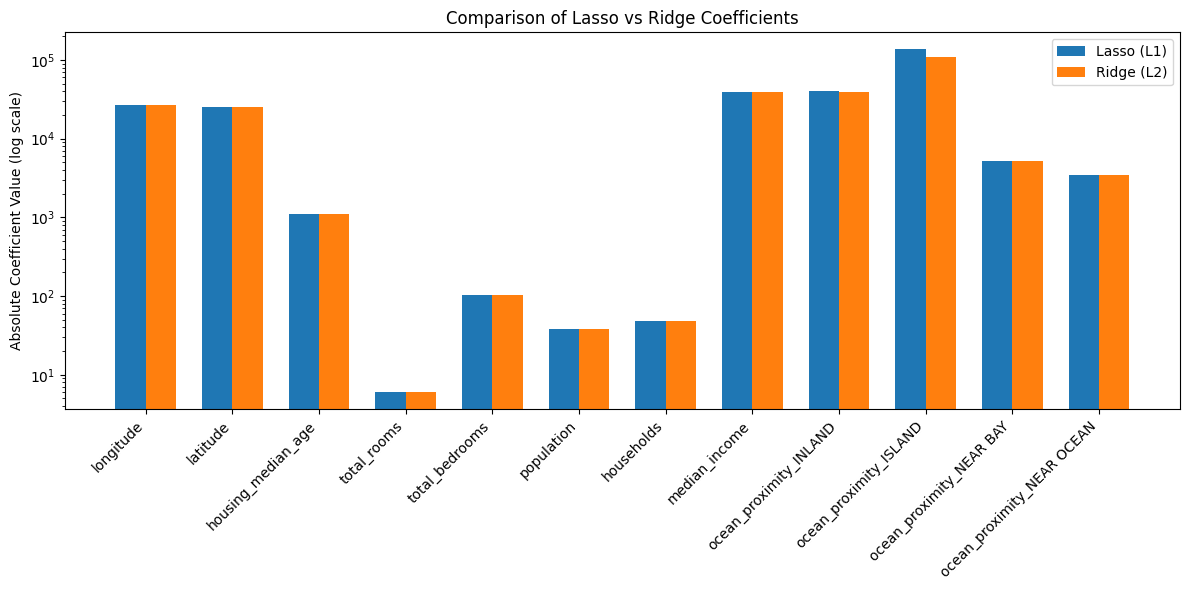

In [64]:
import matplotlib.pyplot as plt
import numpy as np

features = X.columns
x = np.arange(len(features))
width = 0.35

# Absolute coefficients (no max normalization)
lasso_coef_abs = np.abs(lasso_final.coef_)
ridge_coef_abs = np.abs(ridge_final.coef_)

plt.figure(figsize=(12,6))
plt.bar(x - width/2, lasso_coef_abs, width, label='Lasso (L1)')
plt.bar(x + width/2, ridge_coef_abs, width, label='Ridge (L2)')

plt.xticks(x, features, rotation=45, ha='right')
plt.ylabel("Absolute Coefficient Value (log scale)")
plt.title("Comparison of Lasso vs Ridge Coefficients")
plt.yscale('log')  # log scale fixes tiny/big value problem
plt.legend()
plt.tight_layout()
plt.show()




In [72]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

# Load Breast Cancer dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Split into training (80%) and test (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [73]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(max_iter=1000)

logreg.fit(X_train, y_train)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [74]:
import pandas as pd

# Get coefficients
coefficients = logreg.coef_[0]  # 1D array
feature_names = data.feature_names

# Put into a DataFrame for easy viewing
coeff_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

print(coeff_df)


                    Feature  Coefficient
0               mean radius     2.099812
1              mean texture     0.132486
2            mean perimeter    -0.103468
3                 mean area    -0.002556
4           mean smoothness    -0.170243
5          mean compactness    -0.379844
6            mean concavity    -0.691207
7       mean concave points    -0.408107
8             mean symmetry    -0.235070
9    mean fractal dimension    -0.023564
10             radius error    -0.085405
11            texture error     1.122469
12          perimeter error    -0.325757
13               area error    -0.065194
14         smoothness error    -0.023711
15        compactness error     0.059602
16          concavity error     0.004522
17     concave points error    -0.042776
18           symmetry error    -0.041480
19  fractal dimension error     0.014251
20             worst radius     0.966303
21            worst texture    -0.377126
22          worst perimeter    -0.058583
23              

In [75]:
from sklearn.metrics import accuracy_score

# Predict on training and test sets
y_train_pred = logreg.predict(X_train)
y_test_pred = logreg.predict(X_test)

# Compute accuracy
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print("Training Accuracy:", train_acc)
print("Test Accuracy:", test_acc)


Training Accuracy: 0.9582417582417583
Test Accuracy: 0.956140350877193


In [76]:
param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l1", "l2"]
}

In [77]:
logreg = LogisticRegression(solver='liblinear', max_iter=1000)

grid_search = GridSearchCV(
    estimator=logreg,
    param_grid=param_grid,
    cv=5,  # 5-fold cross-validation
    scoring='accuracy'
)

grid_search.fit(X_train, y_train)


GridSearchCV(cv=5,
             estimator=LogisticRegression(max_iter=1000, solver='liblinear'),
             param_grid={'C': [0.01, 0.1, 1, 10, 100], 'penalty': ['l1', 'l2']},
             scoring='accuracy')

In [78]:
print("Best Hyperparameters:", grid_search.best_params_)

best_logreg = grid_search.best_estimator_

train_acc = best_logreg.score(X_train, y_train)
test_acc = best_logreg.score(X_test, y_test)

print("Training Accuracy:", train_acc)
print("Test Accuracy:", test_acc)


Best Hyperparameters: {'C': 100, 'penalty': 'l1'}
Training Accuracy: 0.989010989010989
Test Accuracy: 0.9824561403508771


In [79]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import pandas as pd

# L1 Logistic Regression
logreg_l1 = LogisticRegression(
    penalty='l1',
    C=100,
    solver='liblinear',
    max_iter=1000
)
logreg_l1.fit(X_train, y_train)

# L2 Logistic Regression
logreg_l2 = LogisticRegression(
    penalty='l2',
    C=100,
    solver='lbfgs',
    max_iter=1000
)
logreg_l2.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(C=100, max_iter=1000)

In [80]:
coeff_comparison = pd.DataFrame({
    "Feature": data.feature_names,
    "L1_Coeff": logreg_l1.coef_[0],
    "L2_Coeff": logreg_l2.coef_[0]
})

print(coeff_comparison)

                    Feature    L1_Coeff  L2_Coeff
0               mean radius    0.764435  8.113572
1              mean texture   -0.108668  0.304952
2            mean perimeter    0.097336 -0.812962
3                 mean area   -0.002439 -0.029870
4           mean smoothness    0.000000 -1.490858
5          mean compactness   47.187422 -1.319844
6            mean concavity  -11.907780 -2.840573
7       mean concave points -136.267908 -3.361503
8             mean symmetry   19.707538 -1.909167
9    mean fractal dimension    0.000000  0.102253
10             radius error    0.000000 -0.763082
11            texture error    1.731199  4.231362
12          perimeter error    0.000000 -1.542501
13               area error   -0.197606 -0.050340
14         smoothness error    0.000000 -0.224831
15        compactness error    0.000000  1.811720
16          concavity error   50.154820  2.672632
17     concave points error    0.000000 -0.180771
18           symmetry error   19.019349 -0.065801


In [81]:
# L1 accuracy
train_acc_l1 = accuracy_score(y_train, logreg_l1.predict(X_train))
test_acc_l1 = accuracy_score(y_test, logreg_l1.predict(X_test))

# L2 accuracy
train_acc_l2 = accuracy_score(y_train, logreg_l2.predict(X_train))
test_acc_l2 = accuracy_score(y_test, logreg_l2.predict(X_test))

print("L1 Logistic Regression - Train Accuracy:", train_acc_l1)
print("L1 Logistic Regression - Test Accuracy:", test_acc_l1)
print("L2 Logistic Regression - Train Accuracy:", train_acc_l2)
print("L2 Logistic Regression - Test Accuracy:", test_acc_l2)

L1 Logistic Regression - Train Accuracy: 0.989010989010989
L1 Logistic Regression - Test Accuracy: 0.9824561403508771
L2 Logistic Regression - Train Accuracy: 0.9736263736263736
L2 Logistic Regression - Test Accuracy: 0.956140350877193


L1 and L2 regularization helps to reduce variance by shrinking the model coefficients. This prevents overfitting because the model will be less sensitive to small changes in the training data.

However, if the regularization is too high. the model becomes simple and cannot capture the underlying patterns of the data. This increases bias and can reduce accuracy on both training and test datasets.